# 10b — Decarbonization investment pathways

Covers `chap10_decarbonization_pathway1.m`, `pathway3.m`, `pathway4.m`,
and `chap10_sector1.m`: sector-level CO$_2$/CH$_4$ emission-source
shares, the 2030 clean-energy investment-flow breakdown (as a pie chart,
`pathway3`), the same investment flows further split by GSS
("Green/Social/Sustainability" labelled bond) financing share
(`sector1`), and a critical-minerals supply/demand-gap small-multiples
chart (`pathway4`). All four scripts are self-contained (hardcoded
illustrative data, no external files).

`pathway3` and `sector1` share the same underlying $1310/900/.../70
investment-flow figures, so both are kept — `sector1` isn't a
duplicate, it extends the same data with a GSS-vs-non-GSS sub-split not
present in `pathway3`.

One disclosed simplification: `sector1`'s original MATLAB figure
hand-tunes a per-slice label offset (`pie_delta`, 16 magic-number
`(x, y)` nudges) to keep the 16 pie-slice labels from overlapping on a
printed page. Matplotlib's `autopct`/label placement is used here
instead of reproducing those manual offsets — the data, sort order, and
GSS/non-GSS two-tone coloring scheme are faithful; only the exact label
pixel positions differ.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

color_blue = "#1f77b4"
color_red = "#d62728"
color_violet = "#9467bd"
color_green = "#2ca02c"
color_darkgreen = "#006400"
color_matlab = "#0072BD"  # MATLAB's default blue

## 1. Sector CO$_2$/CH$_4$ emission shares (`chap10_decarbonization_pathway1.m`)

Illustrative shares of global anthropogenic CO$_2$ and CH$_4$ emissions
by source sector.

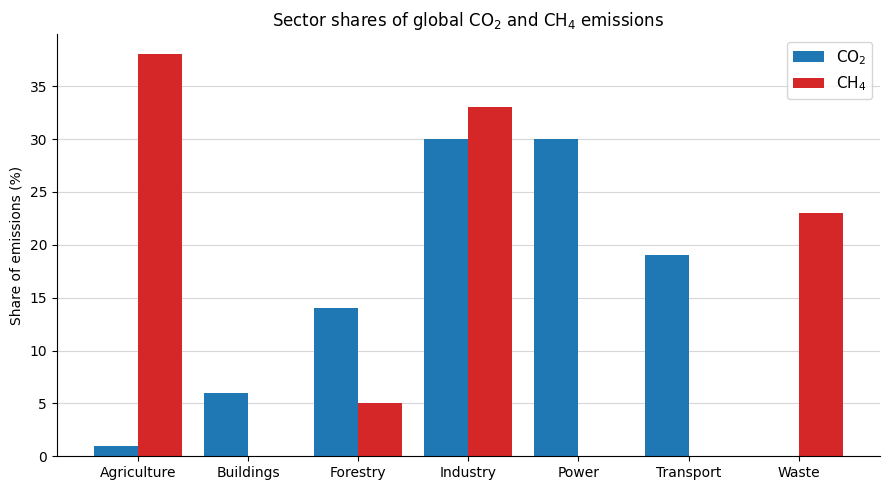

In [2]:
labels = ["Agriculture", "Buildings", "Forestry", "Industry", "Power", "Transport", "Waste"]
CO2 = np.array([1, 6, 14, 30, 30, 19, 0])
CH4 = np.array([38, 0, 5, 33, 0, 0, 23])

x = np.arange(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, CO2, width, label="CO$_2$", color=color_blue)
ax.bar(x + width / 2, CH4, width, label="CH$_4$", color=color_red)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Share of emissions (%)")
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(fontsize=11)
ax.set_title("Sector shares of global CO$_2$ and CH$_4$ emissions")
plt.tight_layout()
plt.show()

## 2. Clean-energy investment flows (`chap10_decarbonization_pathway3.m`)

Illustrative annual clean-energy investment flows (\$bn) by category,
sorted alphabetically, exploding any slice above 10% of the total.

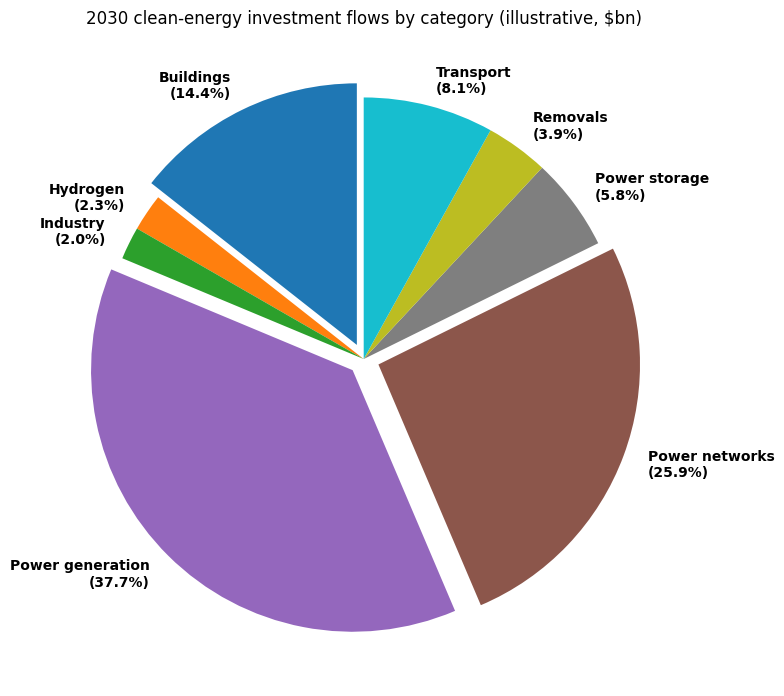

In [3]:
labels3 = ["Power generation", "Power networks", "Power storage", "Buildings",
           "Transport", "Removals", "Hydrogen", "Industry"]
flows = np.array([1310, 900, 200, 500, 280, 135, 80, 70], dtype=float)

order = np.argsort(labels3)
labels3_sorted = [labels3[i] for i in order]
flows_sorted = flows[order]
shares = flows_sorted / flows_sorted.sum()

new_colors = plt.cm.tab10(np.linspace(0, 1, len(labels3_sorted)))
explode = np.where(shares > 0.10, 0.06, 0.0)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    shares,
    explode=explode,
    labels=[f"{lab}\n({100*s:.1f}%)" for lab, s in zip(labels3_sorted, shares)],
    colors=new_colors,
    startangle=90,
    textprops={"fontsize": 10, "fontweight": "bold"},
)
ax.set_title("2030 clean-energy investment flows by category (illustrative, \$bn)")
plt.tight_layout()
plt.show()

## 3. Critical-minerals supply/demand gap (`chap10_decarbonization_pathway4.m`)

For six minerals critical to the clean-energy transition, compares 2022
supply (`S-22`) against three 2030 projections: the central supply
forecast (`S-30`), and the upper/lower bounds of projected demand
(`U-30`/`L-30`) — illustrating the widening supply/demand gap.

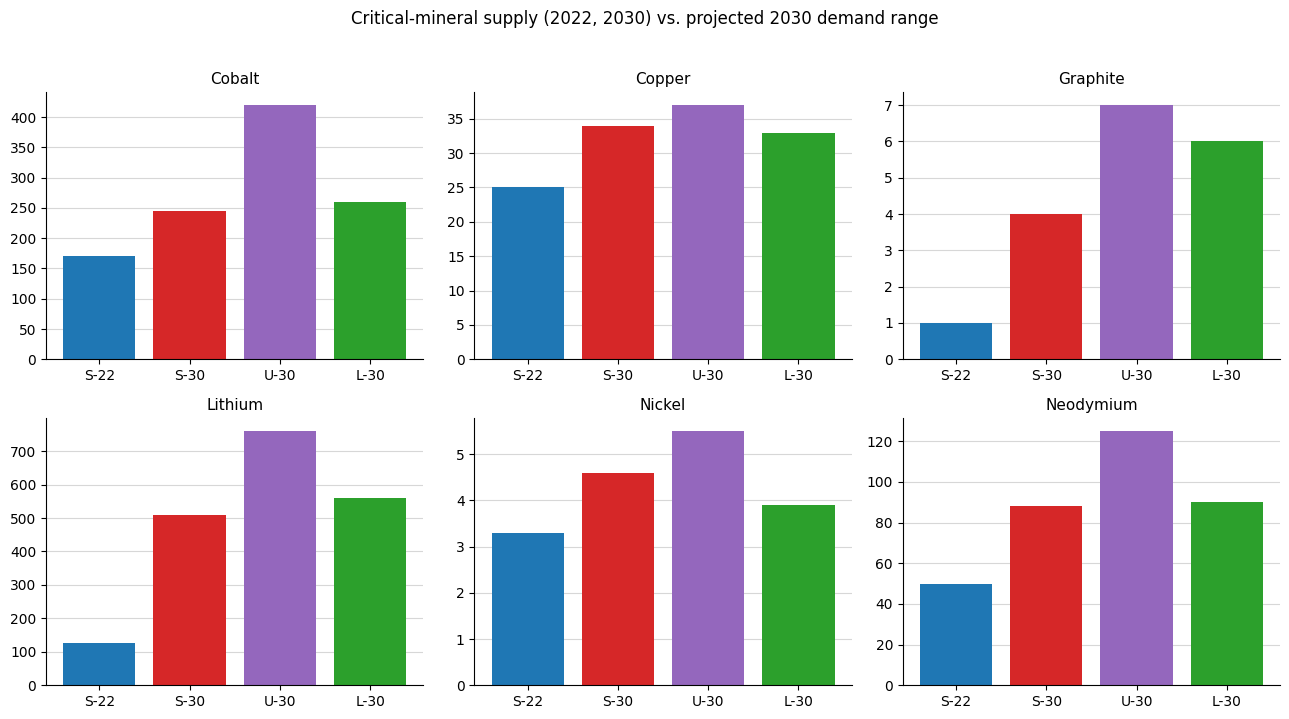

In [4]:
titles4 = ["Cobalt", "Copper", "Graphite", "Lithium", "Nickel", "Neodymium"]
labels4 = ["S-22", "S-30", "U-30", "L-30"]

supply_2022 = np.array([170, 25, 1, 125, 3.3, 50])
supply_2030 = np.array([245, 34, 4, 510, 4.6, 88])
upper_2030 = np.array([420, 37, 7, 760, 5.5, 125])
lower_2030 = np.array([260, 33, 6, 560, 3.9, 90])

colors4 = [color_blue, color_red, color_violet, color_green]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for i, ax in enumerate(axes.flat):
    y = [supply_2022[i], supply_2030[i], upper_2030[i], lower_2030[i]]
    ax.bar(labels4, y, color=colors4)
    ax.set_title(titles4[i], fontsize=11)
    ax.yaxis.grid(True, alpha=0.5)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
fig.suptitle("Critical-mineral supply (2022, 2030) vs. projected 2030 demand range", y=1.02)
plt.tight_layout()
plt.show()

## 4. Investment flows split by GSS financing share (`chap10_sector1.m`)

Same investment-flow data as Section 2, now split into the portion
financed via GSS-labelled bonds (`y_gss`, illustrative shares of a
\$900bn labelled-bond pool applied per category) versus the
non-GSS-financed remainder. The table reproduces the source script's
printed summary; the chart is the 16-slice pie (8 categories x
GSS/non-GSS), sorted alphabetically as in Section 2, with GSS slices in
the darker tone and non-GSS slices in the lighter tone of the same
per-category color (the disclosed label-placement simplification noted
at the top of this notebook applies here).

In [5]:
y = flows.copy()  # same 8-category flows as Section 2, original (unsorted) order
y1 = y / y.sum()
y_gss = 900 * np.array([0.23, 0.15, 0.03, 0.25, 0.20, 0.10, 0.01, 0.03])
y_non_gss = y - y_gss

results = pd.DataFrame({
    "Flow ($bn)": y,
    "Share (%)": 100 * y1,
    "GSS ($bn)": y_gss,
    "GSS share of total (%)": 100 * y_gss / y.sum(),
    "Non-GSS ($bn)": y_non_gss,
    "Non-GSS share of total (%)": 100 * y_non_gss / y.sum(),
    "GSS share of category (%)": 100 * y_gss / y,
}, index=labels3)
results.loc["Total"] = results.sum()
results.loc["Total", "GSS share of category (%)"] = 100 * results.loc["Total", "GSS ($bn)"] / results.loc["Total", "Flow ($bn)"]
display(results.round(1))

,Flow ($bn),Share (%),GSS ($bn),GSS share of total (%),Non-GSS ($bn),Non-GSS share of total (%),GSS share of category (%)
Power generation,1310.0,37.7,207.0,6.0,1103.0,31.7,15.8
Power networks,900.0,25.9,135.0,3.9,765.0,22.0,15.0
Power storage,200.0,5.8,27.0,0.8,173.0,5.0,13.5
Buildings,500.0,14.4,225.0,6.5,275.0,7.9,45.0
Transport,280.0,8.1,180.0,5.2,100.0,2.9,64.3
Removals,135.0,3.9,90.0,2.6,45.0,1.3,66.7
Hydrogen,80.0,2.3,9.0,0.3,71.0,2.0,11.2
Industry,70.0,2.0,27.0,0.8,43.0,1.2,38.6
Total,3475.0,100.0,900.0,25.9,2575.0,74.1,25.9


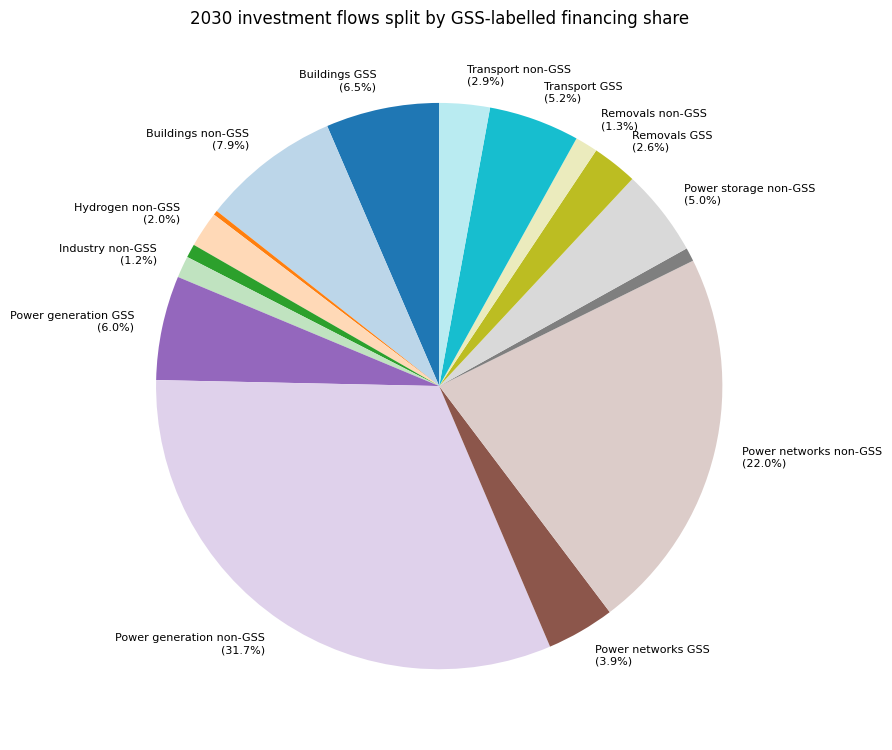

In [6]:
order = np.argsort(labels3)
labels_sorted = [labels3[i] for i in order]
y_gss_sorted = y_gss[order]
y_non_gss_sorted = y_non_gss[order]

base_colors = plt.cm.tab10(np.linspace(0, 1, len(labels_sorted)))
light_colors = base_colors.copy()
light_colors[:, :3] = 0.30 * light_colors[:, :3] + 0.70 * 1.0  # lighten for the non-GSS slices

pie_values, pie_colors, pie_labels = [], [], []
for i, lab in enumerate(labels_sorted):
    pie_values += [y_gss_sorted[i], y_non_gss_sorted[i]]
    pie_colors += [base_colors[i], light_colors[i]]
    pie_labels += [f"{lab} GSS", f"{lab} non-GSS"]

pie_values = np.array(pie_values)
pie_shares = pie_values / pie_values.sum()

fig, ax = plt.subplots(figsize=(9, 9))
ax.pie(
    pie_shares,
    labels=[f"{lab}\n({100*s:.1f}%)" if s > 0.01 else "" for lab, s in zip(pie_labels, pie_shares)],
    colors=pie_colors,
    startangle=90,
    textprops={"fontsize": 8},
)
ax.set_title("2030 investment flows split by GSS-labelled financing share")
plt.tight_layout()
plt.show()